In [21]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import tarfile
import scipy.io

In [2]:
images = pd.read_csv('data/CUB/images.txt', sep=' ', header=None, names=['image_id', 'file_path'])
split = pd.read_csv('data/CUB/train_test_split.txt', sep=' ', header=None, names=['image_id', 'is_training'])
classes = pd.read_csv('data/CUB/image_class_labels.txt', sep=' ', header=None, names=['image_id', 'class_id'])

In [3]:
metadata = images.merge(split, on='image_id').merge(classes, on='image_id')

In [4]:
col_names = ['image_id', 'attribute_id', 'is_present', 'certainty_id', 'time', 'extra']

img_attrs = pd.read_csv('data/CUB/attributes/image_attribute_labels.txt', 
                        sep=r'\s+',  
                        header=None, 
                        names=col_names)

img_attrs = img_attrs[['image_id', 'attribute_id', 'is_present', 'certainty_id']]

In [5]:
attr_matrix = img_attrs.pivot(index='image_id', columns='attribute_id', values='is_present').fillna(0)

In [6]:
df_final = metadata.merge(attr_matrix, on='image_id')

In [7]:
df_final

,image_id,file_path,is_training,class_id,1,2,3,4,5,6,...,303,304,305,306,307,308,309,310,311,312
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,1,0,...,0,0,0,1,0,0,1,0,0,0
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11783,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,1,200,0,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
11784,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,200,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
11785,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,200,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,1,200,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


#### Sprawdzenie empirycznych atrybutów

In [8]:
attributes_df = pd.read_csv('data/CUB/attributes.txt', sep=r'\s+', header=None, names=['attr_id', 'attr_name'])

attr_mapping = dict(zip(attributes_df['attr_id'], attributes_df['attr_name']))

In [9]:
sum_A = attr_matrix.sum(axis=0)
co_occurrence = attr_matrix.T.dot(attr_matrix)

p_B_given_A = co_occurrence.divide(sum_A, axis=0)

np.fill_diagonal(p_B_given_A.values, 0)

threshold = 0.9
strong_relations = np.where(p_B_given_A >= threshold)

print(f"Znaleziono {len(strong_relations[0])} silnych relacji (P > {threshold}):\n")

for a, b in zip(strong_relations[0], strong_relations[1]):
    attr_a_id = attr_matrix.columns[a] 
    attr_b_id = attr_matrix.columns[b]

    name_a = attr_mapping.get(int(attr_a_id), f"Unknown_{attr_a_id}")
    name_b = attr_mapping.get(int(attr_b_id), f"Unknown_{attr_b_id}")

    prob = p_B_given_A.iloc[a, b]

    print(f"{name_a}  -->  {name_b} (Prawdopodobieństwo: {prob:.2f})")

Znaleziono 30 silnych relacji (P > 0.9):

has_bill_shape::cone  -->  has_bill_length::shorter_than_head (Prawdopodobieństwo: 0.95)
has_wing_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.93)
has_wing_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.91)
has_upperparts_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.93)
has_upperparts_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.92)
has_underparts_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.94)
has_underparts_color::yellow  -->  has_belly_color::yellow (Prawdopodobieństwo: 0.90)
has_underparts_color::white  -->  has_belly_color::white (Prawdopodobieństwo: 0.91)
has_back_color::brown  -->  has_upperparts_color::brown (Prawdopodobieństwo: 0.91)
has_back_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.90)
has_back_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.92)
has_back_color::black  -->  has_upperparts_color::black (Prawd

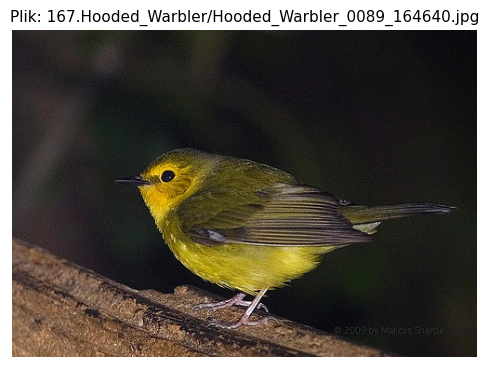

--- Znaleziono 34 aktywnych atrybutów dla tego zdjęcia: ---
✅ has_bill_shape::all-purpose
✅ has_wing_color::grey
✅ has_wing_color::yellow
✅ has_upperparts_color::grey
✅ has_upperparts_color::yellow
✅ has_underparts_color::yellow
✅ has_breast_pattern::multi-colored
✅ has_back_color::grey
✅ has_back_color::yellow
✅ has_upper_tail_color::grey
✅ has_upper_tail_color::black
✅ has_head_pattern::plain
✅ has_breast_color::yellow
✅ has_breast_color::black
✅ has_throat_color::yellow
✅ has_eye_color::black
✅ has_bill_length::shorter_than_head
✅ has_forehead_color::yellow
✅ has_forehead_color::black
✅ has_nape_color::grey
✅ has_nape_color::yellow
✅ has_belly_color::yellow
✅ has_size::very_small_(3_-_5_in)
✅ has_shape::perching-like
✅ has_back_pattern::multi-colored
✅ has_tail_pattern::multi-colored
✅ has_belly_pattern::solid
✅ has_primary_color::grey
✅ has_primary_color::yellow
✅ has_leg_color::buff
✅ has_bill_color::black
✅ has_crown_color::grey
✅ has_crown_color::yellow
✅ has_wing_pattern::multi

In [10]:
base_image_dir = 'data/CUB/images/' 

sample_row = df_final.sample(1).iloc[0]

file_path = sample_row['file_path']
full_path = os.path.join(base_image_dir, file_path)

metadata_cols = ['image_id', 'file_path', 'is_training', 'class_id']
active_attributes = []

for col_name in df_final.columns:
    if col_name not in metadata_cols:
        if sample_row[col_name] == 1.0:
            human_readable_name = attr_mapping.get(int(col_name), f"Atrybut_{col_name}")
            active_attributes.append(human_readable_name)
img = Image.open(full_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Plik: {file_path}", fontsize=11)
plt.show()
print(f"--- Znaleziono {len(active_attributes)} aktywnych atrybutów dla tego zdjęcia: ---")
for attr in active_attributes:
    print(f"✅ {attr}")

#### Sanity check jaki procent ptaków ma czarne oczy do odfiltrowania które relacje mają potencjalnie sens

In [ ]:
black_eye_attr = attributes_df[attributes_df['attr_name'].str.contains('eye_color::black', case=False, na=False)]
black_eye_id = black_eye_attr['attr_id'].iloc[0]
black_eye_name = black_eye_attr['attr_name'].iloc[0]

black_eyes_data = img_attrs[img_attrs['attribute_id'] == black_eye_id]

percentage = (black_eyes_data['is_present'] == 1).mean() * 100

print(f"Atrybut: {black_eye_name} (ID: {black_eye_id})")
print(f"Procent ptaków z czarnymi oczami: {percentage:.2f}%")

Atrybut: has_eye_color::black (ID: 146)
Procent ptaków z czarnymi oczami: 83.75%


#### Relacje po odfiltrowaniu tych oczywistych z czarnymi oczami

In [14]:
threshold = 0.9
strong_relations = np.where(p_B_given_A >= threshold)

count = 0
for a, b in zip(strong_relations[0], strong_relations[1]):
    attr_a_id = attr_matrix.columns[a] 
    attr_b_id = attr_matrix.columns[b]

    name_a = attr_mapping.get(int(attr_a_id), f"Unknown_{attr_a_id}")
    name_b = attr_mapping.get(int(attr_b_id), f"Unknown_{attr_b_id}")

    # Pomijamy relację, jeśli atrybut B (wynikowy) to czarne oczy
    if "eye_color::black" in name_b.lower():
        continue

    prob = p_B_given_A.iloc[a, b]
    
    print(f"{name_a}  -->  {name_b} (Prawdopodobieństwo: {prob:.2f})")
    count += 1

print(f"\n--- Znaleziono {count} relacji po odfiltrowaniu czarnych oczu ---")

has_bill_shape::cone  -->  has_bill_length::shorter_than_head (Prawdopodobieństwo: 0.95)
has_underparts_color::yellow  -->  has_belly_color::yellow (Prawdopodobieństwo: 0.90)
has_underparts_color::white  -->  has_belly_color::white (Prawdopodobieństwo: 0.91)
has_back_color::brown  -->  has_upperparts_color::brown (Prawdopodobieństwo: 0.91)
has_back_color::black  -->  has_upperparts_color::black (Prawdopodobieństwo: 0.90)
has_upper_tail_color::brown  -->  has_wing_color::brown (Prawdopodobieństwo: 0.91)
has_breast_color::yellow  -->  has_underparts_color::yellow (Prawdopodobieństwo: 0.92)
has_belly_color::blue  -->  has_underparts_color::blue (Prawdopodobieństwo: 0.90)
has_belly_color::yellow  -->  has_underparts_color::yellow (Prawdopodobieństwo: 0.94)
has_belly_color::white  -->  has_underparts_color::white (Prawdopodobieństwo: 0.95)

--- Znaleziono 10 relacji po odfiltrowaniu czarnych oczu ---


#### Pierwsza relacja wydaje się potencjalnie ciekawa do zbadania, reszta raczej oczywista (ale w razie czego mozna zbadać kolor tułowia - kolor skrzydeł). Może być ciężko z relacjami empirycznymi

### Relacje wykluczenia (co ze sobą nie współwystępuje)

In [17]:
threshold = 0.01
strong_relations = np.where(p_B_given_A <= threshold)

count = 0
for a, b in zip(strong_relations[0], strong_relations[1]):
    attr_a_id = attr_matrix.columns[a] 
    attr_b_id = attr_matrix.columns[b]

    name_a = attr_mapping.get(int(attr_a_id), f"Unknown_{attr_a_id}")
    name_b = attr_mapping.get(int(attr_b_id), f"Unknown_{attr_b_id}")

    # Pomijamy relację, jeśli atrybut B (wynikowy) to czarne oczy
    if "eye_color::black" in name_b.lower():
        continue

    prob = p_B_given_A.iloc[a, b]
    
    print(f"{name_a}  -->  {name_b} (Prawdopodobieństwo: {prob:.2f})")
    count += 1

print(f"\n--- Znaleziono {count} relacji po odfiltrowaniu czarnych oczu ---")

has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::curved_(up_or_down) (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::dagger (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::hooked (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::needle (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::hooked_seabird (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::spatulate (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::all-purpose (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::cone (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_bill_shape::specialized (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_wing_color::purple (Prawdopodobieństwo: 0.00)
has_bill_shape::curved_(up_or_down)  -->  has_up

#### Jest tego sporo

#### Potencjalny model do przetestowania: 
- https://huggingface.co/anonauthors/cub200-resnet50/tree/main

# Zbiór 2 - SUN

### Zbiór danych ze scenami i przestrzenią wewnątrz/zewnątrz - szybki check atrybutów

In [22]:
mat_attrs = scipy.io.loadmat('data/SUN/SUNAttributeDB/attributes.mat')
mat_images = scipy.io.loadmat('data/SUN/SUNAttributeDB/images.mat')
mat_labels = scipy.io.loadmat('data/SUN/SUNAttributeDB/attributeLabels_continuous.mat')

In [ ]:
attributes_list = [item[0][0] for item in mat_attrs['attributes']]
images_list = [item[0][0] for item in mat_images['images']]
labels_matrix = mat_labels['labels_cv']

In [26]:
threshold = 0.5
binary_labels = (labels_matrix > threshold).astype(float)

df_sun_attributes = pd.DataFrame(binary_labels, columns=attributes_list)

df_sun_attributes.insert(0, 'file_path', images_list)

df_sun_attributes.insert(0, 'image_id', range(1, len(images_list) + 1))

df_sun_attributes.insert(3, 'class_id', df_sun_attributes['file_path'].apply(lambda x: x.split('/')[2]))

print(df_sun_attributes.head())

   image_id                         file_path  sailing/ boating  \
0         1  a/abbey/sun_aakbdcgfpksytcwj.jpg               0.0   
1         2  a/abbey/sun_aaoktempcmudsvna.jpg               0.0   
2         3  a/abbey/sun_abegcweqnetpdlrh.jpg               0.0   
3         4  a/abbey/sun_acguwqihawgzdnju.jpg               0.0   
4         5  a/abbey/sun_acmeiclstytiwnge.jpg               0.0   

                   class_id  driving  biking  transporting things or people  \
0  sun_aakbdcgfpksytcwj.jpg      0.0     0.0                            0.0   
1  sun_aaoktempcmudsvna.jpg      0.0     0.0                            0.0   
2  sun_abegcweqnetpdlrh.jpg      0.0     0.0                            0.0   
3  sun_acguwqihawgzdnju.jpg      0.0     0.0                            0.0   
4  sun_acmeiclstytiwnge.jpg      0.0     0.0                            0.0   

   sunbathing  vacationing/ touring  hiking  ...  far-away horizon  \
0         0.0                   1.0     0.0  ...    

In [28]:
metadata_cols = ['image_id', 'file_path', 'class_id']
attr_matrix_sun = df_sun_attributes.drop(columns=metadata_cols, errors='ignore')
sum_A = attr_matrix_sun.sum(axis=0)
co_occurrence = attr_matrix_sun.T.dot(attr_matrix_sun)
p_B_given_A = co_occurrence.divide(sum_A, axis=0)
np.fill_diagonal(p_B_given_A.values, 0)
threshold = 0.9
strong_relations = np.where(p_B_given_A >= threshold)

print(f"Znaleziono {len(strong_relations[0])} silnych relacji (P > {threshold}):\n")
for a, b in zip(strong_relations[0], strong_relations[1]):
    name_a = attr_matrix_sun.columns[a] 
    name_b = attr_matrix_sun.columns[b]

    prob = p_B_given_A.iloc[a, b]

    print(f"{name_a}  -->  {name_b} (Prawdopodobieństwo: {prob:.2f})")

Znaleziono 8 silnych relacji (P > 0.9):

studying/ learning  -->  enclosed area (Prawdopodobieństwo: 0.95)
research  -->  enclosed area (Prawdopodobieństwo: 0.95)
medical activity  -->  enclosed area (Prawdopodobieństwo: 0.92)
shingles  -->  man-made (Prawdopodobieństwo: 0.97)
carpet  -->  enclosed area (Prawdopodobieństwo: 0.96)
brick  -->  man-made (Prawdopodobieństwo: 0.93)
sterile  -->  enclosed area (Prawdopodobieństwo: 0.94)
far-away horizon  -->  open area (Prawdopodobieństwo: 0.95)


#### Relacje wydają się dość ciekawe.
#### Potencjalny model do zbadania:
- https://github.com/CSAILVision/places365/blob/master/run_placesCNN_basic.py

#### Wyświetlenie obrazów

In [ ]:
images_tar = "C:/Users/Admin/Downloads/SUNAttributeDB_Images.tar.gz"
images_dir = "data/SUN/images"

os.makedirs(images_dir, exist_ok=True)

if os.path.exists(images_tar):
    print("Rozpoczynanie rozpakowywania obrazów (1.7 GB)...")
    with tarfile.open(images_tar, "r:gz") as tar:
        # SUN zazwyczaj wypakowuje się do folderu o nazwie 'images'
        tar.extractall(path="data/SUN/")
    print("Rozpakowano pomyślnie do data/SUN/images/")
else:
    print("Błąd: Nie znaleziono pliku archiwalnego.")